In [1]:
import numpy as np

import matplotlib.pyplot as plt
from cycler import cycler
from coffea import util
from coffea.processor import accumulate
import hist
import hist.intervals

from ttgamma.utils.plotting import (
    RebinHist,
    SetRangeHist,
    GroupBy,
    DictToHist,
    plotWithRatio,
)

In [14]:
from save_to_root import outputMC, outputData

groupingCategory = {
    "NonPrompt": [3j, 4j],
    "MisID": [2j],
    "Prompt": [1j],
}

groupingFineCategory = {
    "Genuine Photon": [1j],
    "Misidentified Electron": [2j],
    "Hadronic Photon": [3j],
    "Hadronic Fake": [4j],
}

groupingMCDatasets = {
    "ZG": [
        "ZGamma_01J_5f_lowMass",
    ],
    "WG": [
        "WGamma",
    ],
    "other": [
        "TTbarPowheg_Dilepton",
        "TTbarPowheg_Semilept",
        "TTbarPowheg_Hadronic",
        "W2jets",
        "W3jets",
        "W4jets",
        "DYjetsM50",
        "ST_s_channel",
        "ST_tW_channel",
        "ST_tbarW_channel",
        "ST_tbar_channel",
        "ST_t_channel",
        "TTWtoLNu",
        "TTWtoQQ",
        "TTZtoLL",
        "GJets_HT200To400",
        "GJets_HT400To600",
        "GJets_HT600ToInf",
        "ZZ",
        "WZ",
        "WW",
        "TGJets",
    ],
    "ttgamma": [
        "TTGamma_Dilepton",
        "TTGamma_SingleLept",
        "TTGamma_Hadronic",
    ],
}
colors = [
    "#e15759",  # ttgamma
    "#59a14f",  # WG
    "#4e79a7",  # ZG
    "#bab0ab",  # other
    "#b07aa1",  # MisID
    "#76b7b2",  # NonPrompt
]

In [3]:
# Group MC histograms
# we want to sort by
'''
outputMC = {
    process: accumulate(outputMC_[ds] for ds in datasets)
    for process, datasets in groupingMCDatasets.items()
}


def getHisto(name):
    return DictToHist(
        {process: histos[name] for process, histos in outputMC.items()}, name="dataset"
    )


# Group data histograms
outputDataHist = accumulate([histo for key, histo in outputData_.items()])\
'''
s = hist.tag.Slicer()

In [4]:
# 1) First reproduce the grouped MC object from your script
outputMC_grouped = {
    process: accumulate(outputMC[ds] for ds in datasets)
    for process, datasets in groupingMCDatasets.items()
}
outputDataHist = accumulate([histo for key, histo in outputData.items()])

def getHisto(name):
    return DictToHist(
        {process: histos[name] for process, histos in outputMC_grouped.items()},
        name="dataset"
    )

# 2) Helper to build the grouped histogram exactly as in your workflow
def build_grouped_hist(name, lepFlavor=sum, rebin_spec=None, axis_range=None):
    """
    name: histogram name, e.g. 'photon_chIso', 'M3', 'photon_lepton_mass_3j0t'
    lepFlavor: sum, 'electron', or 'muon'
    rebin_spec: dict like {"M3": s[50j:550j+1:hist.rebin(4)]}
    axis_range: tuple like ("M3", 50, 550)
    """
    h = getHisto(name)

    # sum/select lepton flavor if that axis exists
    axis_names = [ax.name for ax in h.axes]
    if "lepFlavor" in axis_names:
        h = h[{"lepFlavor": lepFlavor}]

    # collapse fine category -> Prompt / MisID / NonPrompt
    if "category" in axis_names or "category" in [ax.name for ax in h.axes]:
        h = GroupBy(h, "category", "category", groupingCategory)

    # apply optional rebinning/slicing
    if rebin_spec is not None:
        h = h[rebin_spec]

    # apply optional range restriction
    if axis_range is not None:
        axis_name, xmin, xmax = axis_range
        h = SetRangeHist(h, axis_name, xmin, xmax)

    return h

# 3) Extract the six mutually exclusive fit components
def extract_components(h, systematic="nominal"):
    comps = {
        "ttgamma":   h[{"dataset": "ttgamma", "category": "Prompt",    "systematic": systematic}],
        "WG":        h[{"dataset": "WG",      "category": "Prompt",    "systematic": systematic}],
        "ZG":        h[{"dataset": "ZG",      "category": "Prompt",    "systematic": systematic}],
        "other":     h[{"dataset": "other",   "category": "Prompt",    "systematic": systematic}],
        "MisID":     h[{"dataset": sum,       "category": "MisID",     "systematic": systematic}],
        "NonPrompt": h[{"dataset": sum,       "category": "NonPrompt", "systematic": systematic}],
    }
    return comps

# 4) Plot overlay
def plot_components_overlay(
    comps,
    title="",
    normalize=False,
    logy=False,
    linewidth=2
):
    plt.figure(figsize=(8, 6))

    for label, h in comps.items():
        vals = h.values()
        edges = h.axes[0].edges
        centers = 0.5 * (edges[:-1] + edges[1:])

        y = vals.copy()
        if normalize:
            total = np.sum(y)
            if total > 0:
                y = y / total

        plt.step(centers, y, where="mid", label=label, linewidth=linewidth)

    plt.xlabel(h.axes[0].label if h.axes[0].label else h.axes[0].name)
    plt.ylabel("Normalized entries" if normalize else "Entries")
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5) Obtain numpy arrays from histograms (for both dict of hists and just hists)
def components_to_numpy(comps):
    """
    Convert dict of Hist objects into numpy arrays.

    Returns:
        yields_dict   : dict of np arrays (counts per bin)
        errors_dict   : dict of np arrays (stat uncertainties)
        bin_edges     : bin edges
    """

    yields_dict = {}
    errors_dict = {}

    # grab binning from the first histogram
    first_hist = next(iter(comps.values()))
    bin_edges = first_hist.axes[0].edges

    for name, h in comps.items():
        vals = h.values()
        vars_ = h.variances()

        yields_dict[name] = np.array(vals)
        errors_dict[name] = np.sqrt(vars_) if vars_ is not None else np.sqrt(vals)

    return yields_dict, errors_dict, bin_edges

def datahist_to_numpy(h):
    """
    Convert a Hist data histogram into numpy arrays.

    Returns
    -------
    data_vals : np.ndarray
        Observed counts per bin
    data_err  : np.ndarray
        Statistical uncertainties
    bin_edges : np.ndarray
        Bin edges
    """

    data_vals = np.array(h.values())
    variances = h.variances()

    if variances is not None:
        data_err = np.sqrt(variances)
    else:
        # Poisson assumption
        data_err = np.sqrt(data_vals)

    bin_edges = h.axes[0].edges

    return data_vals, data_err, bin_edges

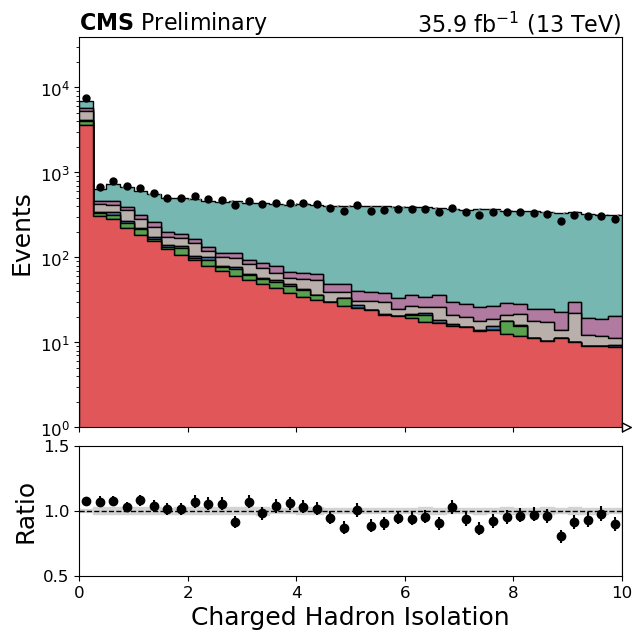

In [32]:
h_chIso = build_grouped_hist(
    "photon_chIso",
    lepFlavor=sum,
    rebin_spec={"chIso": s[:: hist.rebin(5)]},
    axis_range=("chIso", 0, 10),
)

comps_chIso = extract_components(h_chIso, systematic="nominal")
hComp_chIso = DictToHist(comps_chIso, name="dataset")

hData_chIso = outputDataHist["photon_chIso"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_chIso_tmp = hData_chIso[{"chIso": s[:: hist.rebin(5)]}]
hData_chIso = SetRangeHist(hData_chIso_tmp, "chIso", 0, 10)

plotWithRatio(hComp_chIso, hData_chIso, overlay="dataset", logY=True, leg="right", colors=colors, displeg=False)
plt.savefig("./Plots/pref_chIso.png")


In [25]:
#new_bins = np.array([1.1500000000000001, 2.5, 5, 9, 10])
#chIso_axis = hist.axis.Variable(new_bins, name="chIso", label="Charged Hadron Isolation")

#h_iso = build_grouped_hist("photon_chIso", lepFlavor=sum)
#h_iso = RebinHist(h_iso, chIso=chIso_axis)

#comps_iso = extract_components(h_iso, systematic="nominal")
'''plot_components_overlay(
    comps_chIso,
    title="photon_chIso components",
    normalize=False,   # shape comparison
    logy=True
)'''

'plot_components_overlay(\n    comps_chIso,\n    title="photon_chIso components",\n    normalize=False,   # shape comparison\n    logy=True\n)'

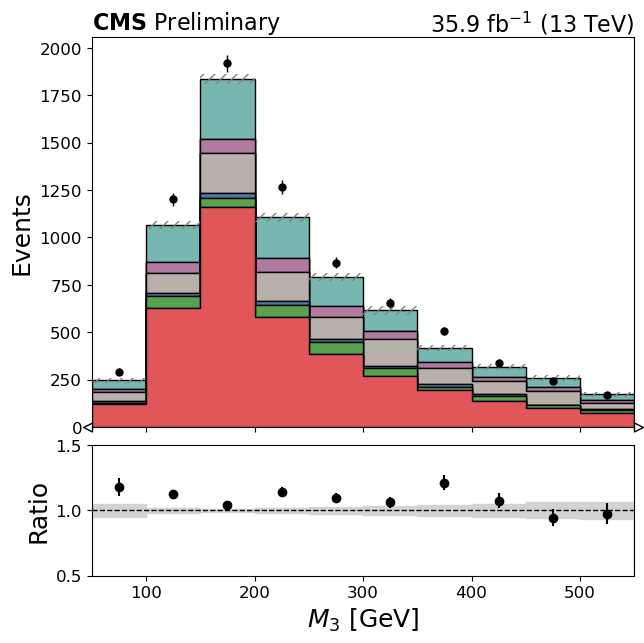

In [33]:
h_m3 = build_grouped_hist(
    "M3",
    lepFlavor=sum,
    rebin_spec={"M3": s[50j:550j+1:hist.rebin(4)]},
    axis_range=("M3", 50, 550),
)

comps_m3 = extract_components(h_m3, systematic="nominal")
hComp_m3 = DictToHist(comps_m3, name="dataset")

hData_m3 = outputDataHist["M3"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_m3_tmp = hData_m3[{"M3": s[50j:550j+1:hist.rebin(4)]}]
hData_m3 = SetRangeHist(hData_m3_tmp, "M3", 50, 550)

plotWithRatio(hComp_m3, hData_m3, overlay="dataset", leg="right", colors=colors, displeg=False)
plt.savefig("./Plots/pref_m3.png")


In [27]:
'''plot_components_overlay(
    comps_m3,
    title="M3 components",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_m3,\n    title="M3 components",\n    normalize=False,\n    logy=False\n)'

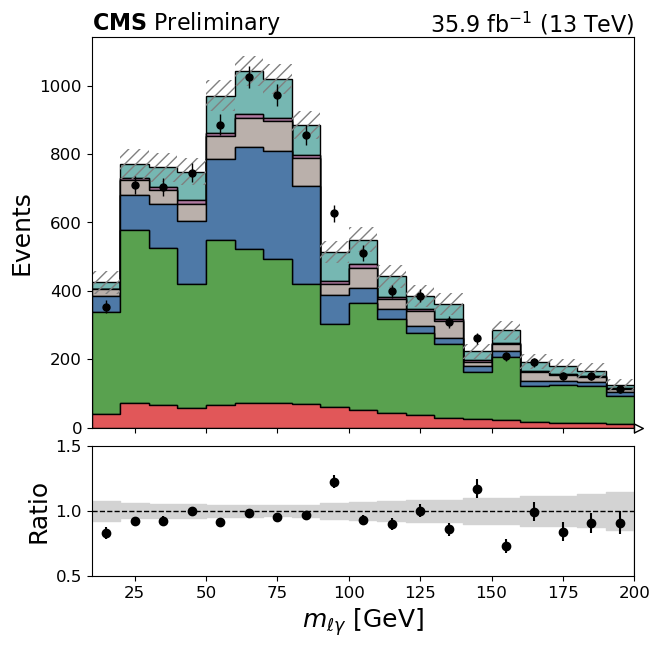

In [34]:
h_mass_mu = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="muon",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_mu = extract_components(h_mass_mu, systematic="nominal")
hComp_mass_mu = DictToHist(comps_mass_mu, name="dataset")

hData_mass_mu = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "muon", "category": sum, "systematic": sum}]
hData_mass_mu_tmp = hData_mass_mu[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_mu = SetRangeHist(hData_mass_mu_tmp, "mass", 10, 200)

plotWithRatio(hComp_mass_mu, hData_mass_mu, overlay="dataset", leg="right", colors=colors, displeg=False)
plt.savefig("./Plots/pref_mass_mu.png")


In [29]:
'''plot_components_overlay(
    comps_mass_mu,
    title="photon-lepton mass components (muon channel)",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_mass_mu,\n    title="photon-lepton mass components (muon channel)",\n    normalize=False,\n    logy=False\n)'

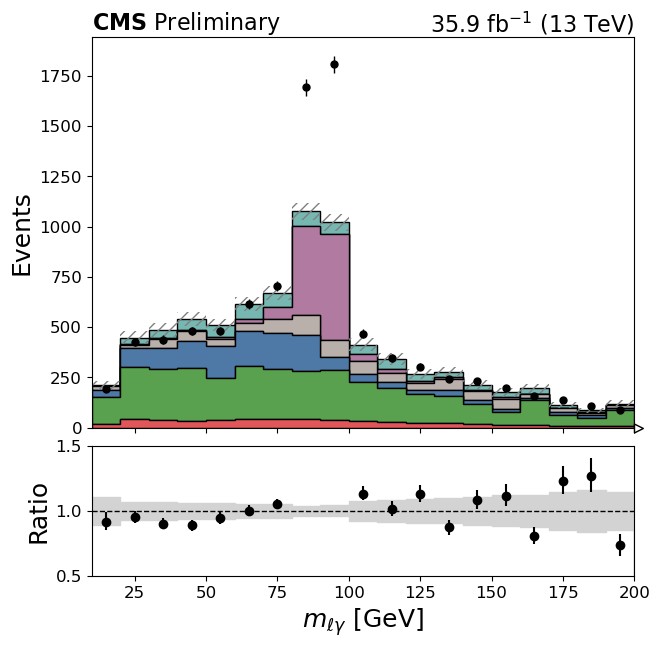

In [35]:
h_mass_el = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="electron",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_el = extract_components(h_mass_el, systematic="nominal")
hComp_mass_el = DictToHist(comps_mass_el, name="dataset")

hData_mass_el = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "electron", "category": sum, "systematic": sum}]
hData_mass_el_tmp = hData_mass_el[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_el = SetRangeHist(hData_mass_el_tmp, "mass", 10, 200)

plotWithRatio(hComp_mass_el, hData_mass_el, overlay="dataset", leg="right", colors=colors, displeg=False)
plt.savefig("./Plots/pref_mass_el.png")


In [31]:
'''plot_components_overlay(
    comps_mass_el,
    title="photon-lepton mass components (electron channel)",
    normalize=False,
    logy=False
)'''

'plot_components_overlay(\n    comps_mass_el,\n    title="photon-lepton mass components (electron channel)",\n    normalize=False,\n    logy=False\n)'

In [23]:
mcvals_chIso, mcerr_chIso, mcedge_chIso = components_to_numpy(comps_chIso)
mcvals_m3, mcerr_m3, mcedge_m3 = components_to_numpy(comps_m3)
mcvals_mass_mu, mcerr_mass_mu, mcedge_mass_mu = components_to_numpy(comps_mass_mu)
mcvals_mass_el, mcerr_mass_el, mcedge_mass_el = components_to_numpy(comps_mass_el)

dvals_chIso, derr_chIso, dedge_chIso = datahist_to_numpy(hData_chIso)
dvals_m3, derr_m3, dedge_m3 = datahist_to_numpy(hData_m3)
dvals_mass_mu, derr_mass_mu, dedge_mass_mu = datahist_to_numpy(hData_mass_mu)
dvals_mass_el, derr_mass_el, dedge_mass_el = datahist_to_numpy(hData_mass_el)

mcvals = {
    "chIso": mcvals_chIso,
    "M3": mcvals_m3,
    "mass_mu": mcvals_mass_mu,
    "mass_el": mcvals_mass_el
}

dvals = {
    "chIso": dvals_chIso,
    "M3": dvals_m3,
    "mass_mu": dvals_mass_mu,
    "mass_el": dvals_mass_el
}

mcerr = {
    "chIso": mcerr_chIso,
    "M3": mcerr_m3,
    "mass_mu": mcerr_mass_mu,
    "mass_el": mcerr_mass_el
}

derr = {
    "chIso": derr_chIso,
    "M3": derr_m3,
    "mass_mu": derr_mass_mu,
    "mass_el": derr_mass_el
}

mcedge = {
    "chIso": mcedge_chIso,
    "M3": mcedge_m3,
    "mass_mu": mcedge_mass_mu,
    "mass_el": mcedge_mass_el
}

dedge = {
    "chIso": dedge_chIso,
    "M3": dedge_m3,
    "mass_mu": dedge_mass_mu,
    "mass_el": dedge_mass_el
}

varnames = [
    "mcvals", "dvals", "mcerr", "derr", "mcedge", "dedge"
]

%store varnames

for name in varnames:
    %store $name

Stored 'varnames' (list)
Stored 'mcvals' (dict)
Stored 'dvals' (dict)
Stored 'mcerr' (dict)
Stored 'derr' (dict)
Stored 'mcedge' (dict)
Stored 'dedge' (dict)
